In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

ModuleNotFoundError: No module named 'matplotlib'

In [2]:
!pip install matplotlib seaborn

  Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl (75 kB)
Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl (7.2 MB)
U

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv("retail_sales_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [5]:
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
df.describe()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate Rows:
0

Statistical Summary:


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [6]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

print("Date converted successfully!")
print(df.dtypes)

Date converted successfully!
Transaction ID               int64
Date                datetime64[us]
Customer ID                    str
Gender                         str
Age                          int64
Product Category               str
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object


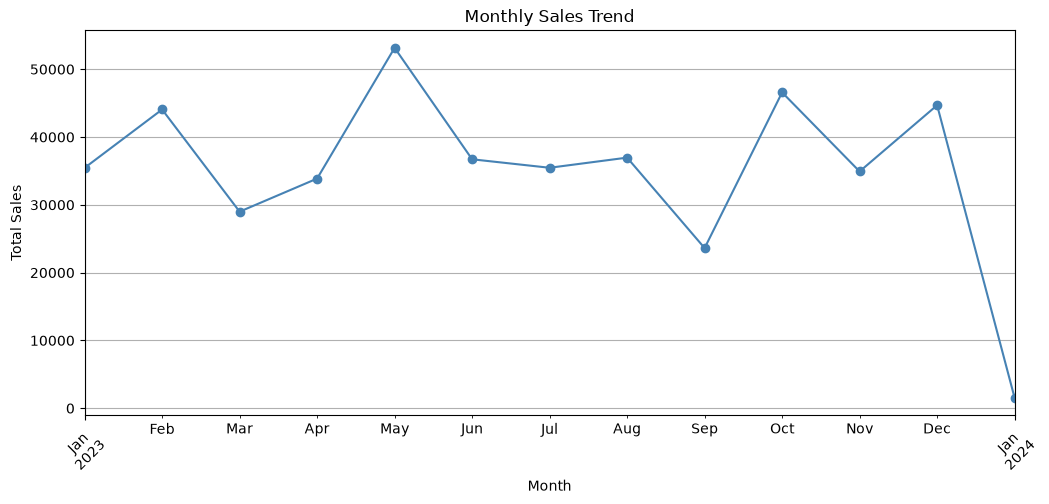

In [7]:
# Create monthly sales data
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

# Plot monthly sales trend
plt.figure(figsize=(12, 5))
monthly_sales.plot(marker='o', color='steelblue')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

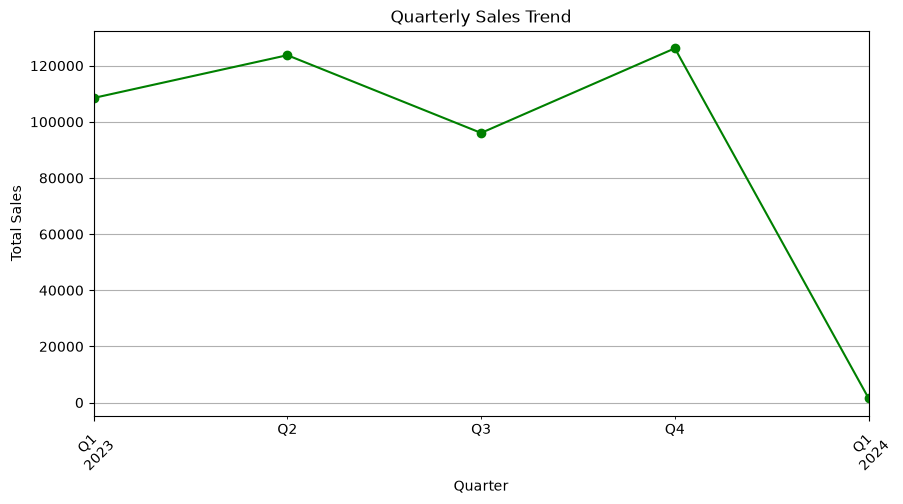

In [8]:
# Create quarterly sales data
quarterly_sales = df.groupby(df['Date'].dt.to_period('Q'))['Total Amount'].sum()

# Plot quarterly sales trend
plt.figure(figsize=(10, 5))
quarterly_sales.plot(marker='o', color='green')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Age Group
18-25    169
26-35    205
36-45    202
46-55    229
56-64    195
Name: count, dtype: int64


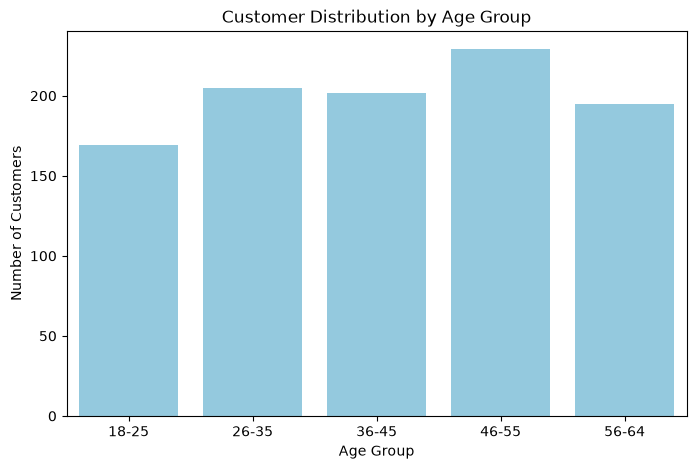

In [9]:
# Create age groups
bins = [17, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56-64']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Count customers in each age group
age_group_counts = df['Age Group'].value_counts().sort_index()

print(age_group_counts)

# Plot age group distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, color='skyblue')

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.show()

Sales by Product Category:
Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


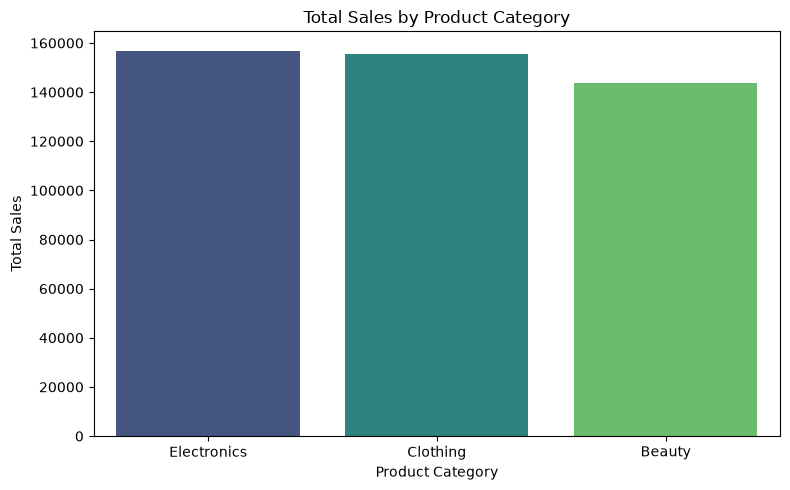

In [10]:
# Sales by Product Category

category_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

print("Sales by Product Category:")
print(category_sales)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    hue=category_sales.index,
    palette='viridis',
    legend=False
)

plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Sales by Gender:
Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


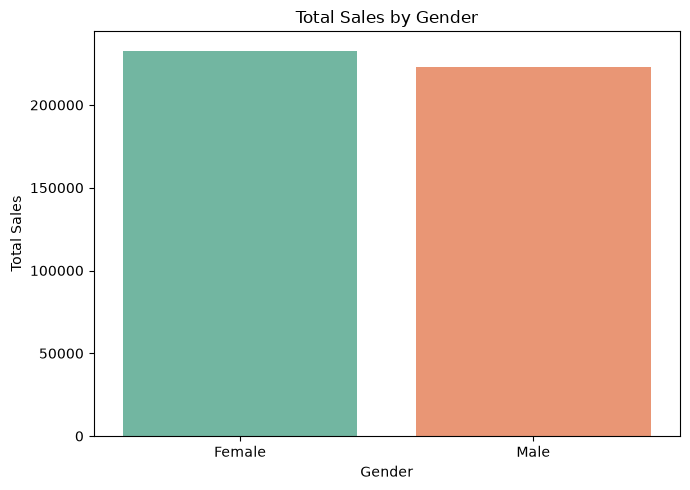

In [11]:
# Sales by Gender

gender_sales = df.groupby('Gender')['Total Amount'].sum().sort_values(ascending=False)

print("Sales by Gender:")
print(gender_sales)

plt.figure(figsize=(7, 5))
sns.barplot(
    x=gender_sales.index,
    y=gender_sales.values,
    hue=gender_sales.index,
    palette='Set2',
    legend=False
)

plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

Monthly Sales:
Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64


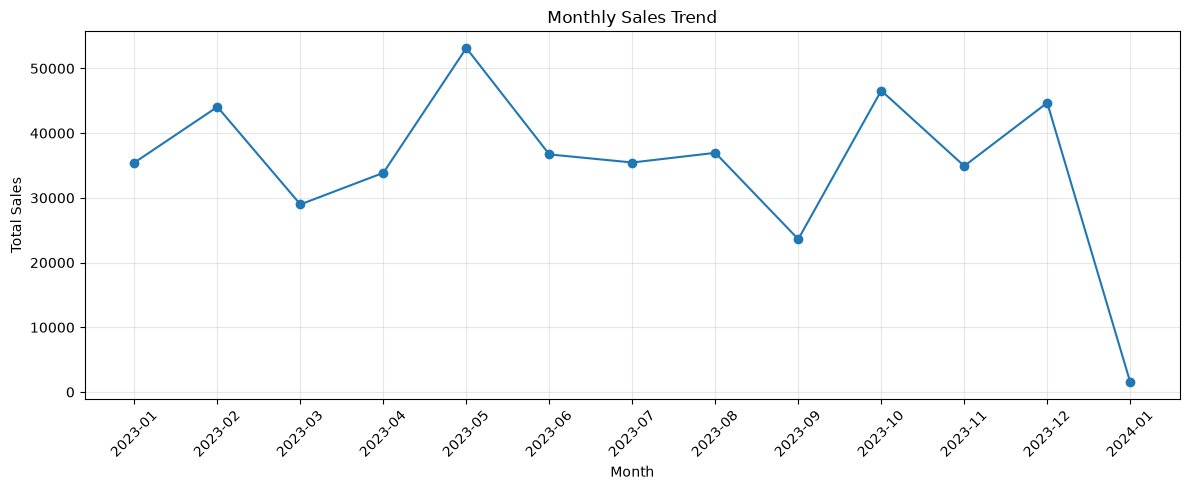

In [12]:
# Monthly Sales Trend

df['Month'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Total Amount'].sum()

print("Monthly Sales:")
print(monthly_sales)

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

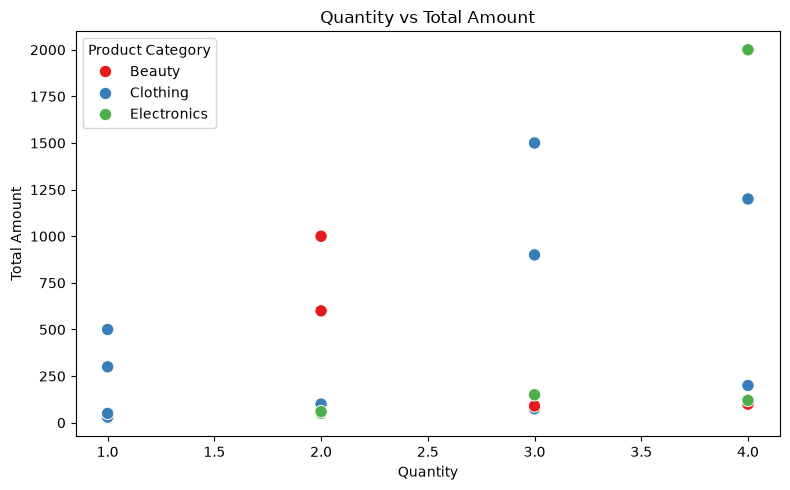

In [13]:
# Quantity vs Total Amount

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Quantity',
    y='Total Amount',
    hue='Product Category',
    palette='Set1',
    s=80
)

plt.title('Quantity vs Total Amount')
plt.xlabel('Quantity')
plt.ylabel('Total Amount')
plt.tight_layout()
plt.show()

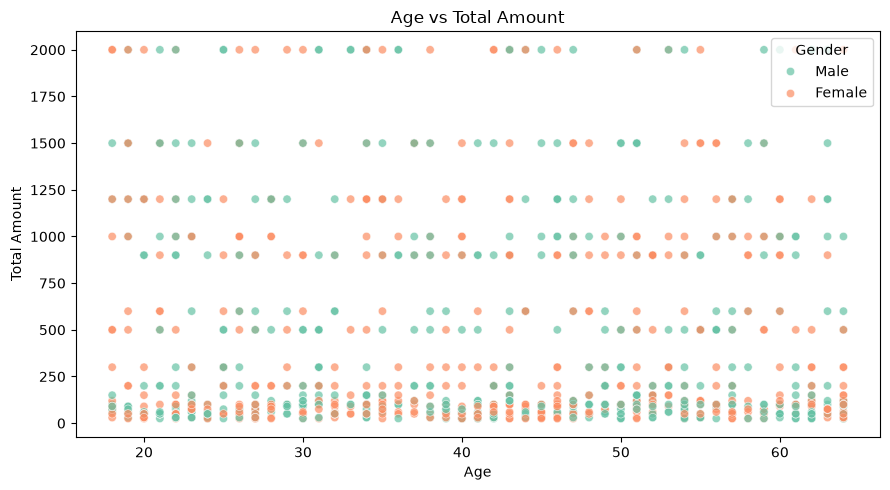

In [14]:
# Age vs Total Amount

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x='Age',
    y='Total Amount',
    hue='Gender',
    palette='Set2',
    alpha=0.7
)

plt.title('Age vs Total Amount')
plt.xlabel('Age')
plt.ylabel('Total Amount')
plt.tight_layout()
plt.show()

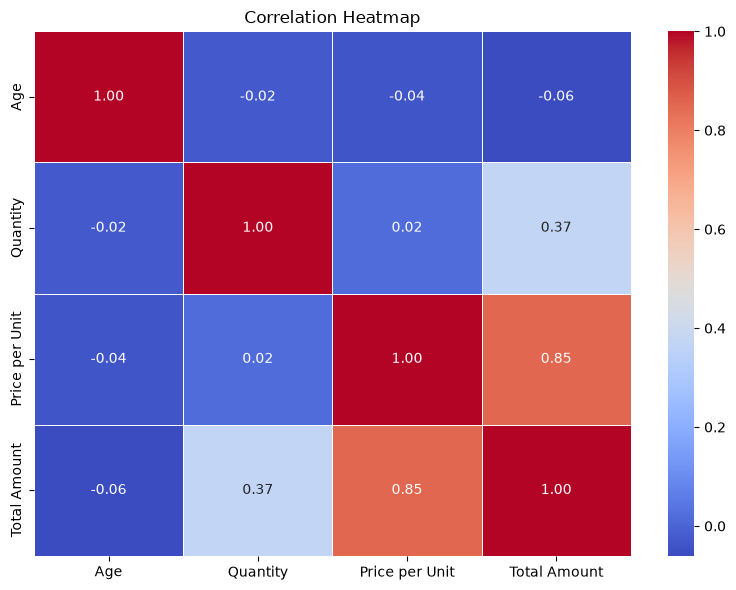

In [15]:
# Correlation Heatmap

numeric_cols = [
    'Age',
    'Quantity',
    'Price per Unit',
    'Total Amount'
]

correlation = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [16]:
# Key Business Insights

top_category = category_sales.idxmax()
top_category_sales = category_sales.max()

top_gender = gender_sales.idxmax()
top_gender_sales = gender_sales.max()

best_month = monthly_sales.idxmax()
best_month_sales = monthly_sales.max()

print("KEY BUSINESS INSIGHTS")
print("-" * 40)

print(f"1. Highest-selling category: {top_category}")
print(f"   Total sales: {top_category_sales:,}")

print(f"\n2. Highest sales by gender: {top_gender}")
print(f"   Total sales: {top_gender_sales:,}")

print(f"\n3. Best sales month: {best_month}")
print(f"   Total sales: {best_month_sales:,}")

print(f"\n4. Average transaction value: {df['Total Amount'].mean():,.2f}")

print(f"5. Average customer age: {df['Age'].mean():.1f} years")

print(f"6. Average quantity per transaction: {df['Quantity'].mean():.2f}")

KEY BUSINESS INSIGHTS
----------------------------------------
1. Highest-selling category: Electronics
   Total sales: 156,905

2. Highest sales by gender: Female
   Total sales: 232,840

3. Best sales month: 2023-05
   Total sales: 53,150

4. Average transaction value: 456.00
5. Average customer age: 41.4 years
6. Average quantity per transaction: 2.51
